Weight Update Analysis for LDP Robustness Explanation
=====================================================
GraphSAGE + FedAvgM + Label Flip at 20% and 40% poisoning

Compares client weight update vectors across three conditions:
  1. Clean (no poison, no LDP)
  2. Poisoned (no LDP, no clipping)
  3. Poisoned + LDP (clip δ=1.0, Laplace noise on weights)

Metrics:
  - Update norm: ||Δw_i|| for each client
  - Cosine similarity: alignment between each client's update and the mean clean update
  - Inter-client agreement: pairwise cosine similarity among clients


In [1]:
# Cell 1: Imports and Setup
import os
import torch
import numpy as np
import pandas as pd
import random
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from torch.nn.utils import clip_grad_norm_
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [3]:
# Cell 3: Graph Construction and Poisoning
feature_prefixes = ["XM", "XS", "XB", "XD", "XL", "XP", "XF", "XE"]

def create_graph_from_df(df, k=5, label_col="label"):
    feature_cols = [col for prefix in feature_prefixes for col in df.columns if col.startswith(prefix)]
    x = torch.tensor(df[feature_cols].values, dtype=torch.float)
    y = torch.tensor(df[label_col].values, dtype=torch.long)
    num_nodes = x.shape[0]
    knn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    knn.fit(x)
    knn_graph = knn.kneighbors_graph(x).toarray()
    edge_list = [[i, j] for i in range(num_nodes) for j in range(num_nodes)
                 if knn_graph[i, j] and i != j]
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    train_idx, val_idx = train_test_split(np.arange(num_nodes), test_size=0.2, random_state=42)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    return Data(x=x, y=y, edge_index=edge_index, train_mask=train_mask, val_mask=val_mask)

def poison_label_flip(df, label_col="label", percentage=1.0):
    df = df.copy()
    n = int(len(df) * percentage)
    idx = np.random.choice(df.index, n, replace=False)
    unique_labels = sorted(df[label_col].unique())
    label_map = {l: unique_labels[(i + 1) % len(unique_labels)] for i, l in enumerate(unique_labels)}
    df.loc[idx, label_col] = df.loc[idx, label_col].map(label_map)
    return df



In [4]:
# Cell 4: Training Functions — NO clip (non-LDP) and WITH clip (LDP)
def local_train_no_clip(model, data, optimizer, loss_fn, local_epochs=5):
    """Training WITHOUT gradient clipping (matches your non-LDP setup)."""
    model.train()
    for _ in range(local_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    return model.state_dict()

def local_train_with_clip(model, data, optimizer, loss_fn, local_epochs=5, CLIP=1.0):
    """Training WITH gradient clipping (matches your LDP setup)."""
    model.train()
    for _ in range(local_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=CLIP)
        optimizer.step()
    return model.state_dict()



In [5]:
# Cell 5: Aggregation (FedAvgM)
def fedavgm(updates, global_weights, momentum_buffer, beta=0.9):
    delta = {}
    for key in global_weights:
        delta[key] = sum(update[key] - global_weights[key] for update in updates) / len(updates)
        momentum_buffer[key] = beta * momentum_buffer.get(key, torch.zeros_like(delta[key])) + delta[key]
    new_global_weights = {k: global_weights[k] + momentum_buffer[k] for k in global_weights}
    return new_global_weights, momentum_buffer



In [6]:
# Cell 6: Utility functions for update vector analysis
def get_update_vector(state_dict, global_weights):
    """Flatten the weight delta (client update - global weights) into a single vector."""
    deltas = []
    for key in global_weights:
        delta = (state_dict[key] - global_weights[key]).flatten()
        deltas.append(delta)
    return torch.cat(deltas)

def cosine_sim(v1, v2):
    """Cosine similarity between two vectors."""
    return F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()

def compute_update_norm(state_dict, global_weights):
    """L2 norm of the weight update."""
    total = 0.0
    for key in global_weights:
        total += ((state_dict[key] - global_weights[key]) ** 2).sum().item()
    return total ** 0.5



In [7]:
# Cell 7: Load Data
data_path = "federated_data"
client_ids = ["client1", "client2", "client3", "client4", "client5"]

client_dfs = []
for cid in client_ids:
    path = os.path.join(data_path, cid, "los_data.csv")
    df = pd.read_csv(path)
    client_dfs.append(df)

test_graph = torch.load(
    os.path.join(data_path, "test", "knn_k5_los_data.pt"),
    map_location=device, weights_only=False
).to(device)

print(f"Loaded {len(client_dfs)} client datasets")



Loaded 5 client datasets


In [8]:
# Cell 8: Main Experiment
def run_update_analysis(poisoned_client_indices, num_runs=5):
    """
    For each FL round, train under four conditions and log update vectors:
      1. Clean (no poison, no clip, no noise)
      2. Clean + LDP (no poison, clip δ=1.0, Laplace noise on weights)
      3. Poisoned (no clip, no noise)
      4. Poisoned + LDP (clip δ=1.0, Laplace noise on weights)
    
    Metrics logged per client per round:
      - Update norm ||Δw||
      - Cosine similarity to mean clean update direction
    """
    num_rounds = 100
    local_epochs = 5
    lr = 1e-4
    CLIP = 1.0
    LAMBDA = 100
    beta = 0.9

    all_logs = []

    for run in range(num_runs):
        print(f"\n{'='*60}")
        print(f"Run {run+1}/{num_runs} | Poisoned clients: {poisoned_client_indices}")
        print(f"{'='*60}")

        # Prepare clean and poisoned data
        clean_dfs = [df.copy() for df in client_dfs]
        poisoned_dfs = []
        for i, df in enumerate(client_dfs):
            if i in poisoned_client_indices:
                poisoned_dfs.append(poison_label_flip(df, percentage=1.0))
            else:
                poisoned_dfs.append(df.copy())

        clean_graphs = [create_graph_from_df(df, k=5).to(device) for df in clean_dfs]
        poison_graphs = [create_graph_from_df(df, k=5).to(device) for df in poisoned_dfs]

        # Compute class weights for each condition
        def get_loss_fn(graphs):
            train_labels = torch.cat([d.y[d.train_mask] for d in graphs]).cpu().numpy()
            classes = np.unique(train_labels)
            cw = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
            cw = torch.tensor(cw, dtype=torch.float).to(device)
            return torch.nn.CrossEntropyLoss(weight=cw, label_smoothing=0.05)

        loss_fn_clean = get_loss_fn(clean_graphs)
        loss_fn_poison = get_loss_fn(poison_graphs)

        # Model factory
        in_ch = clean_graphs[0].num_node_features
        out_ch = clean_graphs[0].y.max().item() + 1
        def model_fn():
            return GraphSAGE(in_ch, 64, out_ch).to(device)

        # Initialize FOUR separate FL pipelines with same initial weights
        init_model = model_fn()
        init_weights = deepcopy(init_model.state_dict())

        gw_clean     = deepcopy(init_weights)
        gw_clean_ldp = deepcopy(init_weights)  
        gw_poison    = deepcopy(init_weights)
        gw_ldp       = deepcopy(init_weights)

        mb_clean     = {}
        mb_clean_ldp = {}  
        mb_poison    = {}
        mb_ldp       = {}

        # LDP noise scale (matching your notebook)
        EPS = (2 * CLIP * num_rounds) / LAMBDA
        scale = lr * 2 * CLIP / np.sqrt(1) / EPS

        for rnd in range(1, num_rounds + 1):
            states_clean     = []
            states_clean_ldp = []  
            states_poison    = []
            states_ldp       = []

            round_logs = []

            for i in range(5):
                # ── Condition 1: Clean (no poison, no clip) ──
                m1 = model_fn(); m1.load_state_dict(gw_clean)
                opt1 = torch.optim.Adam(m1.parameters(), lr=lr, weight_decay=5e-4)
                sd1 = local_train_no_clip(m1, clean_graphs[i], opt1, loss_fn_clean, local_epochs)
                states_clean.append(sd1)

                # ── Condition 2: Clean + LDP (no poison, clip + noise) ──  
                m2 = model_fn(); m2.load_state_dict(gw_clean_ldp)
                opt2 = torch.optim.Adam(m2.parameters(), lr=lr, weight_decay=5e-4)
                sd2 = local_train_with_clip(m2, clean_graphs[i], opt2, loss_fn_clean, local_epochs, CLIP)
                for k, v in sd2.items():
                    if torch.is_floating_point(v):
                        noise = torch.tensor(
                            np.random.laplace(0, scale, v.shape),
                            dtype=v.dtype, device=v.device
                        )
                        sd2[k] = v + noise
                states_clean_ldp.append(sd2)

                # ── Condition 3: Poisoned (no clip, no noise) ──
                m3 = model_fn(); m3.load_state_dict(gw_poison)
                opt3 = torch.optim.Adam(m3.parameters(), lr=lr, weight_decay=5e-4)
                sd3 = local_train_no_clip(m3, poison_graphs[i], opt3, loss_fn_poison, local_epochs)
                states_poison.append(sd3)

                # ── Condition 4: Poisoned + LDP (clip + noise) ──
                m4 = model_fn(); m4.load_state_dict(gw_ldp)
                opt4 = torch.optim.Adam(m4.parameters(), lr=lr, weight_decay=5e-4)
                sd4 = local_train_with_clip(m4, poison_graphs[i], opt4, loss_fn_poison, local_epochs, CLIP)
                for k, v in sd4.items():
                    if torch.is_floating_point(v):
                        noise = torch.tensor(
                            np.random.laplace(0, scale, v.shape),
                            dtype=v.dtype, device=v.device
                        )
                        sd4[k] = v + noise
                states_ldp.append(sd4)

            # Compute update vectors and metrics
            # Reference: mean clean update direction
            clean_updates = [get_update_vector(sd, gw_clean) for sd in states_clean]
            mean_clean_update = torch.stack(clean_updates).mean(dim=0)

            for i in range(5):
                is_poisoned = i in poisoned_client_indices

                uv_clean     = get_update_vector(states_clean[i],     gw_clean)
                uv_clean_ldp = get_update_vector(states_clean_ldp[i], gw_clean_ldp)  
                uv_poison    = get_update_vector(states_poison[i],    gw_poison)
                uv_ldp       = get_update_vector(states_ldp[i],       gw_ldp)

                round_logs.append({
                    "run": run, "round": rnd, "client": i,
                    "is_poisoned": is_poisoned,
                    # Update norms
                    "norm_clean":     uv_clean.norm().item(),
                    "norm_clean_ldp": uv_clean_ldp.norm().item(),  
                    "norm_poison":    uv_poison.norm().item(),
                    "norm_ldp":       uv_ldp.norm().item(),
                    # Cosine similarity to mean clean direction
                    "cos_sim_clean":     cosine_sim(uv_clean,     mean_clean_update),
                    "cos_sim_clean_ldp": cosine_sim(uv_clean_ldp, mean_clean_update),  
                    "cos_sim_poison":    cosine_sim(uv_poison,    mean_clean_update),
                    "cos_sim_ldp":       cosine_sim(uv_ldp,       mean_clean_update),
                })

            # Aggregate (FedAvgM) for each condition
            gw_clean,     mb_clean     = fedavgm(states_clean,     gw_clean,     mb_clean,     beta)
            gw_clean_ldp, mb_clean_ldp = fedavgm(states_clean_ldp, gw_clean_ldp, mb_clean_ldp, beta)  
            gw_poison,    mb_poison    = fedavgm(states_poison,    gw_poison,    mb_poison,    beta)
            gw_ldp,       mb_ldp       = fedavgm(states_ldp,       gw_ldp,       mb_ldp,       beta)

            if rnd % 1 == 0:
                clean_cos     = np.mean([l["cos_sim_clean"]     for l in round_logs[-5:]])
                clean_ldp_cos = np.mean([l["cos_sim_clean_ldp"] for l in round_logs[-5:]]) 
                poison_cos    = np.mean([l["cos_sim_poison"]    for l in round_logs[-5:] if l["is_poisoned"]])
                ldp_cos       = np.mean([l["cos_sim_ldp"]       for l in round_logs[-5:] if l["is_poisoned"]])
                print(f"  Round {rnd:3d} | Cos-sim to clean dir — "
                      f"Clean: {clean_cos:.4f}, Clean+LDP: {clean_ldp_cos:.4f}, "
                      f"Poison: {poison_cos:.4f}, Poison+LDP: {ldp_cos:.4f}")

            all_logs.extend(round_logs)

    return pd.DataFrame(all_logs)

In [9]:
# Cell 9: Run experiments
print("\n" + "="*70)
print("EXPERIMENT 1: 20% Poisoning (1 client)")
print("="*70)
df_20 = run_update_analysis(poisoned_client_indices=[0], num_runs=5)
df_20.to_csv("update_analysis_20pct.csv", index=False)

print("\n" + "="*70)
print("EXPERIMENT 2: 40% Poisoning (2 clients)")
print("="*70)
df_40 = run_update_analysis(poisoned_client_indices=[0, 1], num_runs=5)
df_40.to_csv("update_analysis_40pct.csv", index=False)




EXPERIMENT 1: 20% Poisoning (1 client)

Run 1/5 | Poisoned clients: [0]
  Round   1 | Cos-sim to clean dir — Clean: 0.9405, Clean+LDP: 0.5819, Poison: 0.6914, Poison+LDP: 0.5504
  Round   2 | Cos-sim to clean dir — Clean: 0.9138, Clean+LDP: 0.6471, Poison: 0.6468, Poison+LDP: 0.5865
  Round   3 | Cos-sim to clean dir — Clean: 0.9390, Clean+LDP: 0.6390, Poison: 0.7750, Poison+LDP: 0.6189
  Round   4 | Cos-sim to clean dir — Clean: 0.9266, Clean+LDP: 0.6788, Poison: 0.6912, Poison+LDP: 0.6298
  Round   5 | Cos-sim to clean dir — Clean: 0.9370, Clean+LDP: 0.6917, Poison: 0.5408, Poison+LDP: 0.5719
  Round   6 | Cos-sim to clean dir — Clean: 0.9402, Clean+LDP: 0.6626, Poison: 0.7655, Poison+LDP: 0.6243
  Round   7 | Cos-sim to clean dir — Clean: 0.9473, Clean+LDP: 0.5644, Poison: 0.7751, Poison+LDP: 0.5534
  Round   8 | Cos-sim to clean dir — Clean: 0.9527, Clean+LDP: 0.4401, Poison: 0.7037, Poison+LDP: 0.3881
  Round   9 | Cos-sim to clean dir — Clean: 0.9581, Clean+LDP: 0.2999, Poison: 

In [12]:
# Cell 10: Analysis and Visualization
def analyze_results(df_20, df_40):
    
    # ── Summary Table ──
    print("\n" + "="*70)
    print("SUMMARY TABLE: Update Norms and Cosine Similarity to Clean Direction")
    print("="*70)
    
    rows = []
    for df, pct in [(df_20, "20%"), (df_40, "40%")]:
        for is_p in [False, True]:
            subset = df[df["is_poisoned"] == is_p]
            label = "Poisoned" if is_p else "Clean"
            rows.append({
                "Poison Level": pct,
                "Client Type": label,
                "Update Norm (clean)":     f"{subset['norm_clean'].mean():.4f}±{subset['norm_clean'].std():.4f}",
                "Update Norm (clean+LDP)": f"{subset['norm_clean_ldp'].mean():.4f}±{subset['norm_clean_ldp'].std():.4f}",  # NEW
                "Update Norm (poison)":    f"{subset['norm_poison'].mean():.4f}±{subset['norm_poison'].std():.4f}",
                "Update Norm (LDP)":       f"{subset['norm_ldp'].mean():.4f}±{subset['norm_ldp'].std():.4f}",
                "Cos-Sim (clean)":         f"{subset['cos_sim_clean'].mean():.4f}",
                "Cos-Sim (clean+LDP)":     f"{subset['cos_sim_clean_ldp'].mean():.4f}",  # NEW
                "Cos-Sim (poison)":        f"{subset['cos_sim_poison'].mean():.4f}",
                "Cos-Sim (poison+LDP)":    f"{subset['cos_sim_ldp'].mean():.4f}",
            })
    
    table_df = pd.DataFrame(rows)
    print(table_df.to_string(index=False))
    table_df.to_csv("update_analysis_summary.csv", index=False)
    
    # ── Figure 1: Cosine Similarity Over Rounds ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for col, (df, pct_label) in enumerate([(df_20, "20% Poisoning"), (df_40, "40% Poisoning")]):
        
        # Top row: Poisoned clients
        ax = axes[0, col]
        poison_df = df[df["is_poisoned"]]
        for metric, label, color, ls in [
            ("cos_sim_clean",     "Clean (baseline)",   "#4CAF50", "-"),
            ("cos_sim_clean_ldp", "Clean + LDP",        "#FF9800", "-."),   # NEW
            ("cos_sim_poison",    "Poisoned (no LDP)",  "#F44336", "--"),
            ("cos_sim_ldp",       "Poisoned + LDP",     "#2196F3", "-"),
        ]:
            by_round = poison_df.groupby("round")[metric].agg(["mean", "std"]).reset_index()
            ax.plot(by_round["round"], by_round["mean"], label=label, color=color, linewidth=1.5, linestyle=ls)
            ax.fill_between(by_round["round"],
                            by_round["mean"] - by_round["std"],
                            by_round["mean"] + by_round["std"],
                            alpha=0.15, color=color)
        ax.set_title(f"Poisoned Clients — {pct_label}", fontweight="bold")
        ax.set_xlabel("Communication Round")
        ax.set_ylabel("Cosine Similarity to Clean Direction")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.5, 1.1)
        
        # Bottom row: Clean clients
        ax = axes[1, col]
        clean_df = df[~df["is_poisoned"]]
        for metric, label, color, ls in [
            ("cos_sim_clean",     "Clean (baseline)",              "#4CAF50", "-"),
            ("cos_sim_clean_ldp", "Clean + LDP",                   "#FF9800", "-."),   # NEW
            ("cos_sim_poison",    "With poisoned peers (no LDP)",  "#F44336", "--"),
            ("cos_sim_ldp",       "With poisoned peers + LDP",     "#9C27B0", "-"),
        ]:
            by_round = clean_df.groupby("round")[metric].agg(["mean", "std"]).reset_index()
            ax.plot(by_round["round"], by_round["mean"], label=label, color=color, linewidth=1.5, linestyle=ls)
            ax.fill_between(by_round["round"],
                            by_round["mean"] - by_round["std"],
                            by_round["mean"] + by_round["std"],
                            alpha=0.15, color=color)
        ax.set_title(f"Clean Clients — {pct_label}", fontweight="bold")
        ax.set_xlabel("Communication Round")
        ax.set_ylabel("Cosine Similarity to Clean Direction")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.5, 1.1)
    
    plt.tight_layout()
    plt.savefig("update_cosine_similarity.png", dpi=300, bbox_inches="tight")
    plt.savefig("update_cosine_similarity.pdf", dpi=300, bbox_inches="tight")
    print("\nSaved: update_cosine_similarity.png/pdf")
    plt.show()
    
    # ── Figure 2: Update Norm Comparison ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (df, title) in zip(axes, [
        (df_20, "20% Poisoning"), (df_40, "40% Poisoning")
    ]):
        # Bar chart: update norms by condition and client type
        conditions = ["Clean", "Clean\n+ LDP", "Poison\n(no LDP)", "Poison\n+ LDP"]  # NEW
        x = np.arange(len(conditions))
        width = 0.35
        
        for offset, (is_p, label, colors) in enumerate([
            (False, "Clean Clients",   ["#A5D6A7", "#FFE082", "#EF9A9A", "#90CAF9"]),   # NEW color added
            (True,  "Poisoned Clients",["#388E3C", "#F9A825", "#C62828", "#1565C0"]),   # NEW color added
        ]):
            subset = df[df["is_poisoned"] == is_p]
            means = [
                subset["norm_clean"].mean(),
                subset["norm_clean_ldp"].mean(),   # NEW
                subset["norm_poison"].mean(),
                subset["norm_ldp"].mean(),
            ]
            stds = [
                subset["norm_clean"].std(),
                subset["norm_clean_ldp"].std(),    # NEW
                subset["norm_poison"].std(),
                subset["norm_ldp"].std(),
            ]
            
            positions = x + (offset - 0.5) * width
            ax.bar(positions, means, width * 0.9, yerr=stds,
                   label=label, color=colors, edgecolor="black", linewidth=0.5, capsize=4)
        
        ax.set_xticks(x)
        ax.set_xticklabels(conditions)
        ax.set_ylabel("Mean Update Norm ||Δw||")
        ax.set_title(f"Weight Update Norms — {title}", fontweight="bold")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("update_norms_comparison.png", dpi=300, bbox_inches="tight")
    plt.savefig("update_norms_comparison.pdf", dpi=300, bbox_inches="tight")
    print("Saved: update_norms_comparison.png/pdf")
    plt.show()
    
    # ── Print interpretation ──
    print("\n" + "="*70)
    print("INTERPRETATION")
    print("="*70)
    
    for df, pct in [(df_20, "20%"), (df_40, "40%")]:
        poison_sub = df[df["is_poisoned"]]
        print(f"\n{pct} Poisoning — Poisoned clients' cosine similarity to clean direction:")
        print(f"  Baseline (clean):     {poison_sub['cos_sim_clean'].mean():.4f}")
        print(f"  Clean + LDP:          {poison_sub['cos_sim_clean_ldp'].mean():.4f}")   # NEW
        print(f"  Poisoned (no LDP):    {poison_sub['cos_sim_poison'].mean():.4f}")
        print(f"  Poisoned + LDP:       {poison_sub['cos_sim_ldp'].mean():.4f}")
        
        print(f"\n  Update norms (poisoned clients):")
        print(f"  Clean:      {poison_sub['norm_clean'].mean():.4f}")
        print(f"  Clean+LDP:  {poison_sub['norm_clean_ldp'].mean():.4f}")   # NEW
        print(f"  Poison:     {poison_sub['norm_poison'].mean():.4f}")
        print(f"  LDP:        {poison_sub['norm_ldp'].mean():.4f}")


SUMMARY TABLE: Update Norms and Cosine Similarity to Clean Direction
Poison Level Client Type Update Norm (clean) Update Norm (clean+LDP) Update Norm (poison) Update Norm (LDP) Cos-Sim (clean) Cos-Sim (clean+LDP) Cos-Sim (poison) Cos-Sim (poison+LDP)
         20%       Clean       0.2359±0.0449           0.2601±0.0538        0.2359±0.0427     0.2661±0.0488          0.7758              0.0947           0.1930               0.0933
         20%    Poisoned       0.2369±0.0450           0.2474±0.0518        0.2885±0.0164     0.2881±0.0339          0.7782              0.1017           0.1644               0.0906
         40%       Clean       0.2332±0.0453           0.2644±0.0536        0.2462±0.0370     0.2799±0.0404          0.7547              0.0950           0.1521               0.0909
         40%    Poisoned       0.2333±0.0457           0.2465±0.0516        0.2781±0.0188     0.2863±0.0298          0.7557              0.1021           0.1422               0.0922

Saved: update_cosin

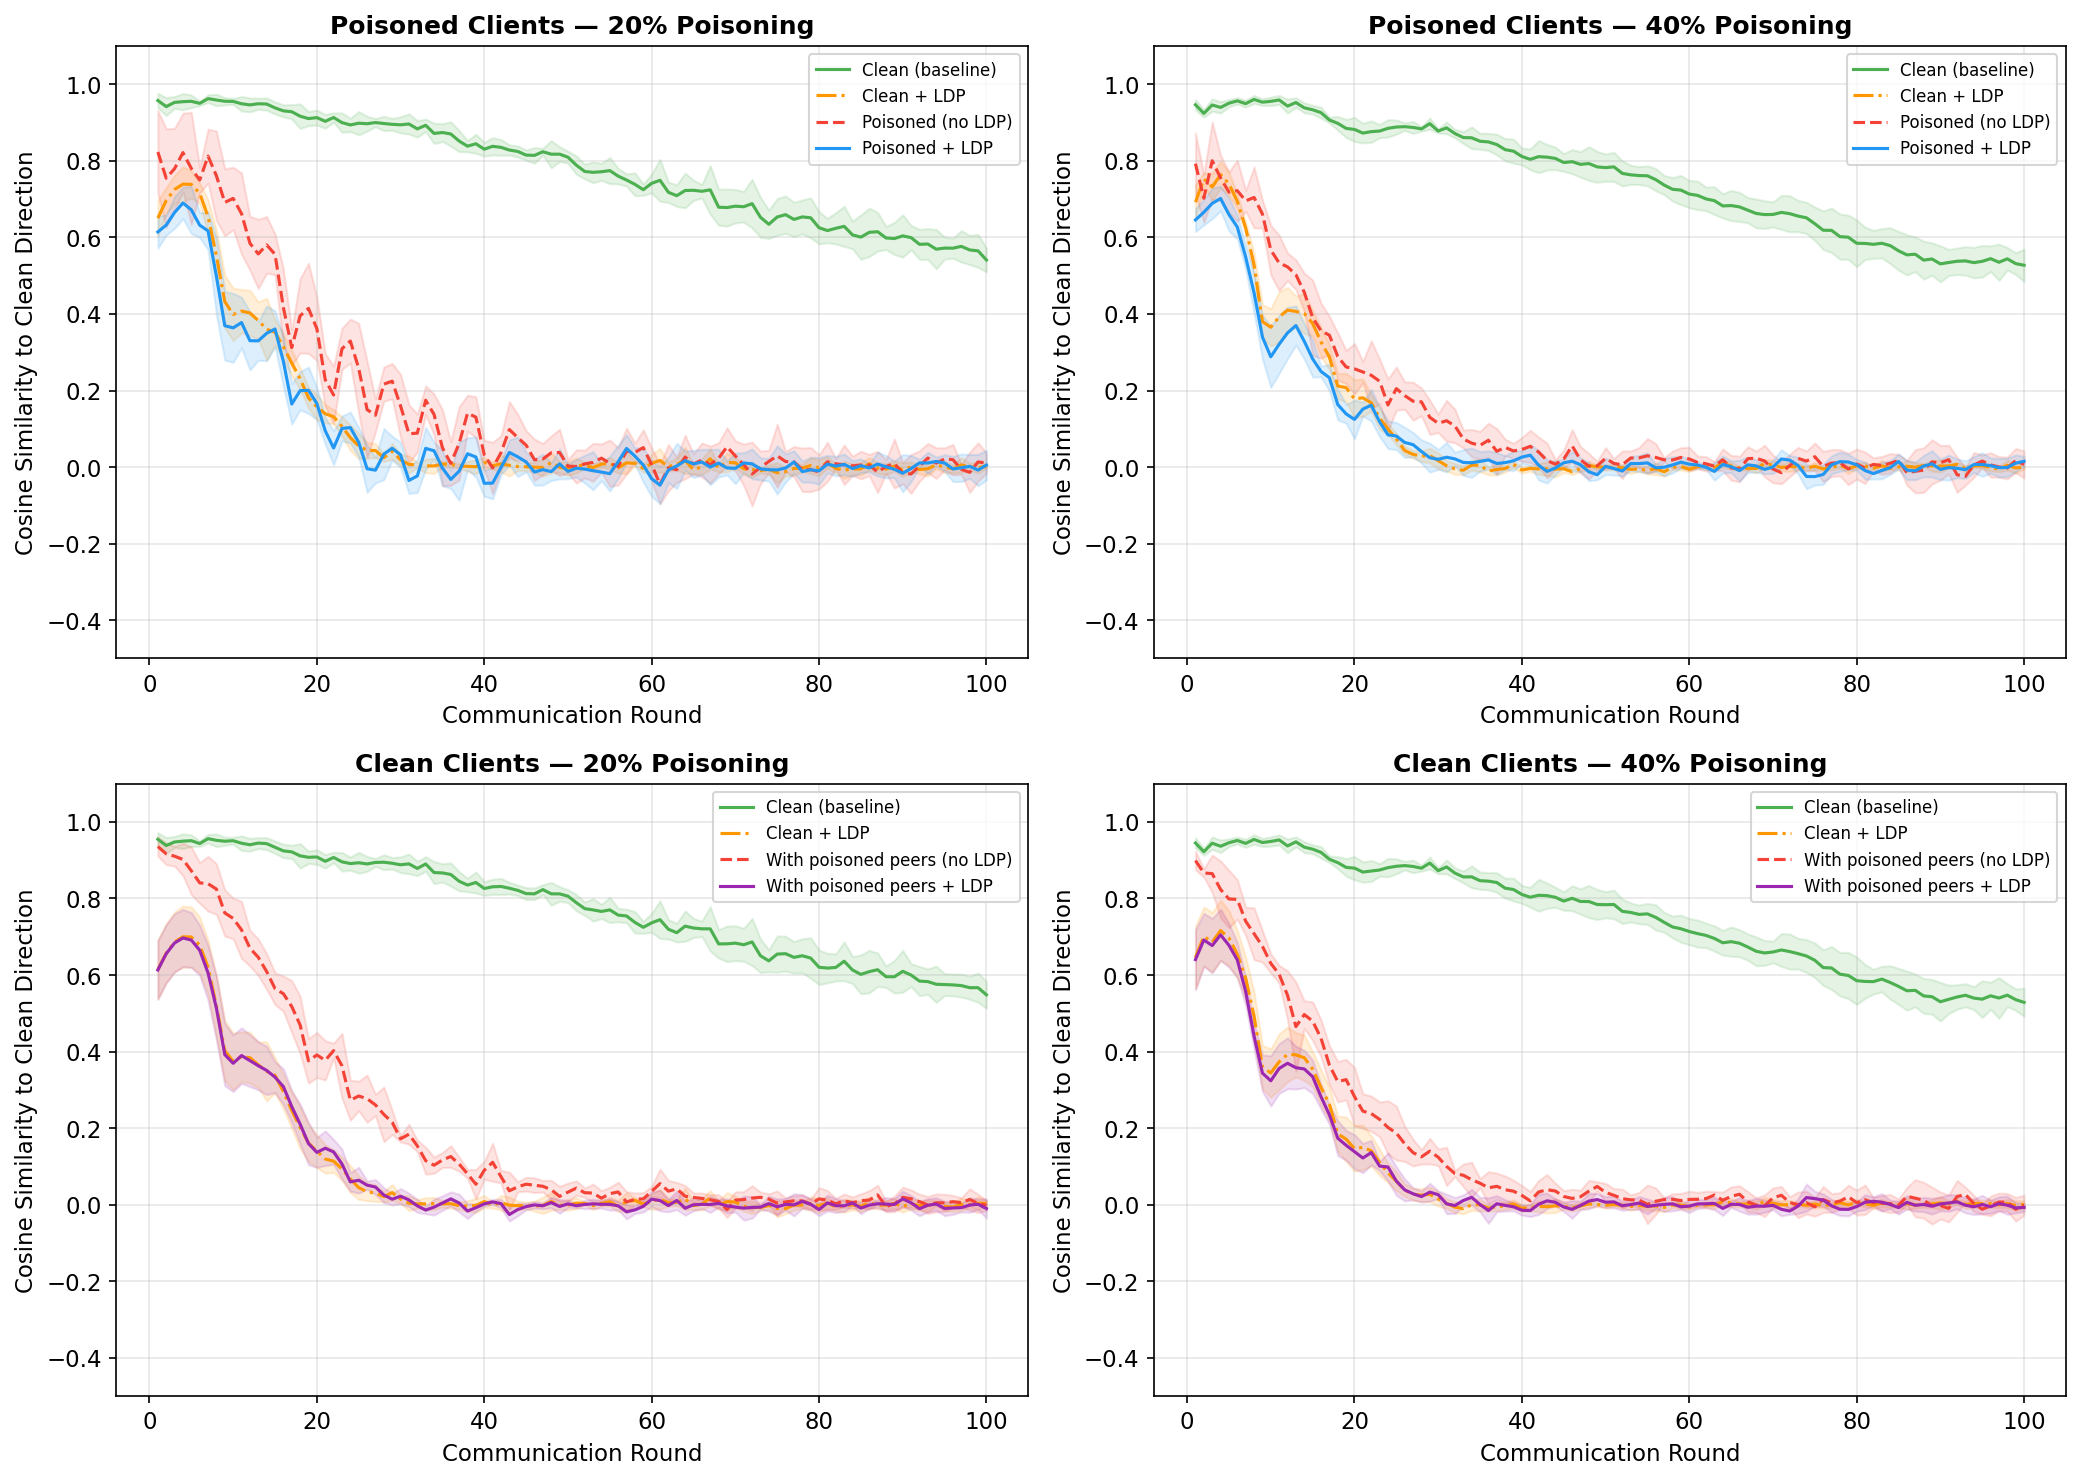

Saved: update_norms_comparison.png/pdf


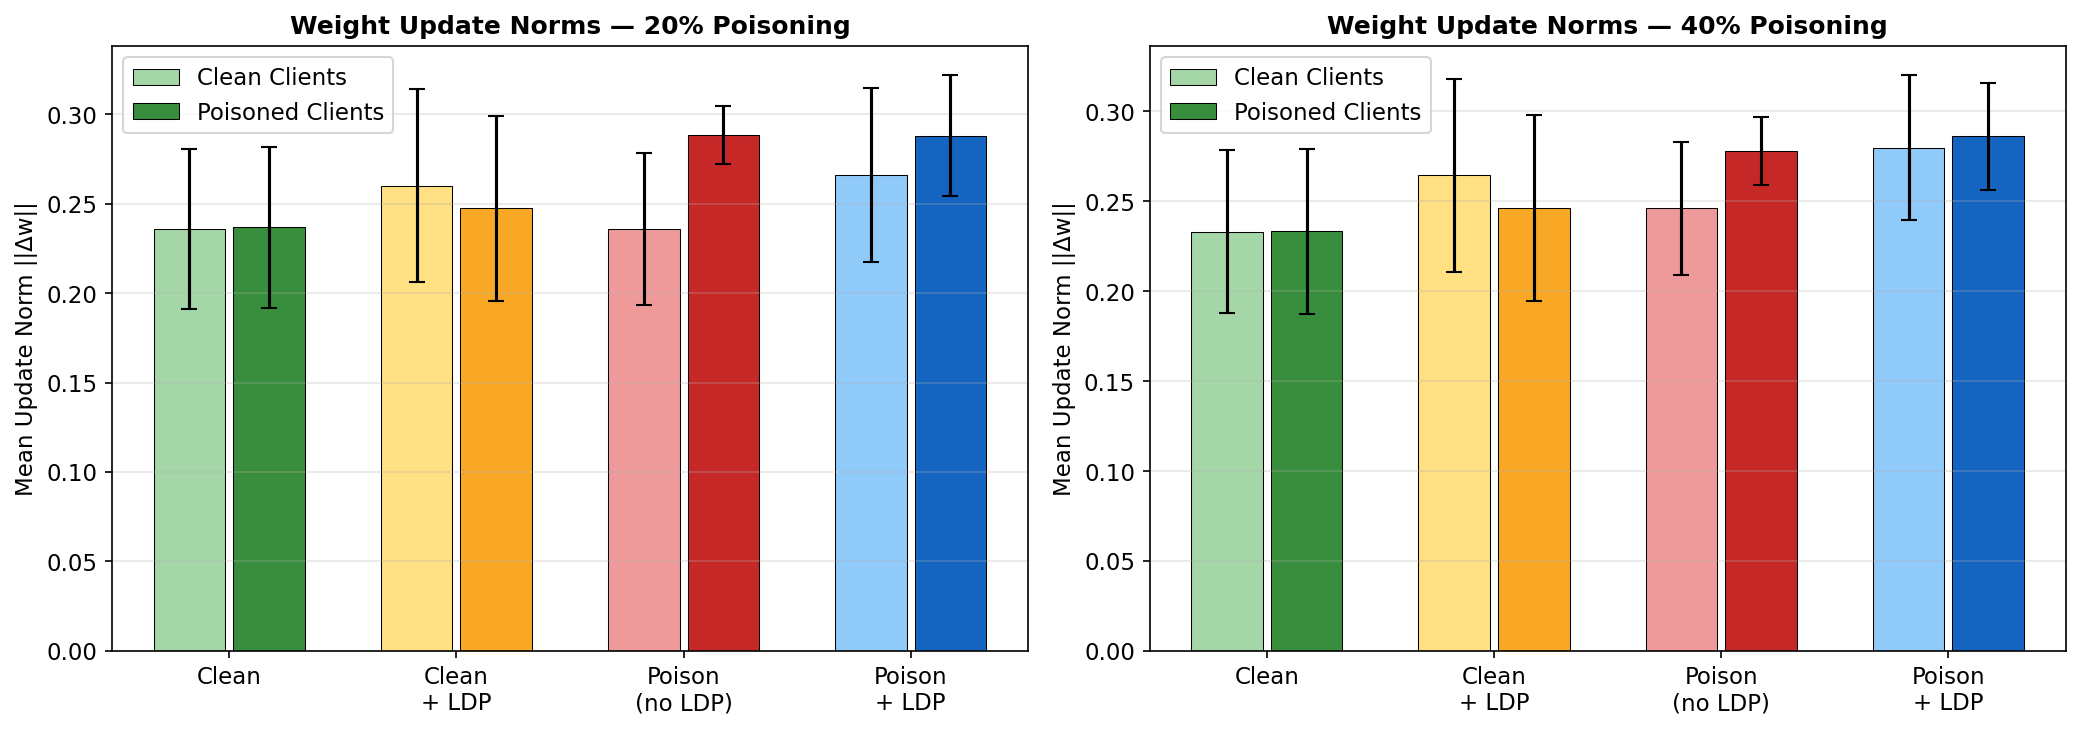


INTERPRETATION

20% Poisoning — Poisoned clients' cosine similarity to clean direction:
  Baseline (clean):     0.7782
  Clean + LDP:          0.1017
  Poisoned (no LDP):    0.1644
  Poisoned + LDP:       0.0906

  Update norms (poisoned clients):
  Clean:      0.2369
  Clean+LDP:  0.2474
  Poison:     0.2885
  LDP:        0.2881

40% Poisoning — Poisoned clients' cosine similarity to clean direction:
  Baseline (clean):     0.7557
  Clean + LDP:          0.1021
  Poisoned (no LDP):    0.1422
  Poisoned + LDP:       0.0922

  Update norms (poisoned clients):
  Clean:      0.2333
  Clean+LDP:  0.2465
  Poison:     0.2781
  LDP:        0.2863

EXPERIMENT COMPLETE

Output files:
  - update_analysis_20pct.csv       (raw per-client, per-round data)
  - update_analysis_40pct.csv       (raw per-client, per-round data)
  - update_analysis_summary.csv     (summary table for paper)
  - update_cosine_similarity.png/pdf (cosine similarity over rounds)
  - update_norms_comparison.png/pdf  (update 

In [13]:
# Cell 11: Run analysis
analyze_results(df_20, df_40)

print("\n" + "="*70)
print("EXPERIMENT COMPLETE")
print("="*70)
print("""
Output files:
  - update_analysis_20pct.csv       (raw per-client, per-round data)
  - update_analysis_40pct.csv       (raw per-client, per-round data)
  - update_analysis_summary.csv     (summary table for paper)
  - update_cosine_similarity.png/pdf (cosine similarity over rounds)
  - update_norms_comparison.png/pdf  (update norm bar chart)

What to look for:
  1. Poisoned clients WITHOUT LDP should have LOW or NEGATIVE cosine 
     similarity to the clean update direction (updates point wrong way)
  2. With LDP, poisoned clients' updates should either:
     a) Have REDUCED norms (clipping bounds their influence), or
     b) Have RANDOMIZED direction (noise drowns out the poison signal)
  3. Clean clients should maintain HIGH cosine similarity in all conditions
  
  The combination of (a) and (b) explains why LDP improves robustness:
  poisoned updates are both bounded in magnitude and randomized in 
  direction, reducing their ability to systematically corrupt the 
  global model.
""")
